# BMRA raw-data assessment and preprocessing

Inspect the current workbook, assess missingness and class columns, then apply a small amount of explicit cleanup. Missing values are preserved.

In [1]:
from collections import Counter
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd
import yaml

In [2]:
ROOT = Path.cwd().resolve()
if not (ROOT / "data/raw").exists():
    ROOT = ROOT.parent
if not (ROOT / "data/raw").exists():
    raise FileNotFoundError("Run this notebook from the repository or notebooks directory")

raw_files = sorted((ROOT / "data/raw").glob("*.xlsx"))
if not raw_files:
    raise FileNotFoundError("No XLSX workbook found in data/raw")
raw_path = raw_files[0]
framework_path = ROOT / "configs/framework.yaml"
with framework_path.open(encoding="utf-8") as file:
    framework_config = yaml.safe_load(file)
project_config_path = ROOT / framework_config["project"]["config_path"]
print(raw_path)

/media/chnguyen47/ADATA/Projects/BMRA_modular_MLC/data/raw/DATA MACHINE LEARNING - CƠ XƯƠNG KHỚP.xlsx


## Workbook overview

In [3]:
workbook = pd.ExcelFile(raw_path)
sheet_summary = []
for sheet_name in workbook.sheet_names:
    sheet = pd.read_excel(raw_path, sheet_name=sheet_name)
    sheet_summary.append(
        {"sheet": sheet_name, "rows": len(sheet), "columns": len(sheet.columns)}
    )
pd.DataFrame(sheet_summary)

,sheet,rows,columns
0,SPSS,1538,402
1,MAPPING,31,9


In [4]:
MISSING_TOKENS = ["", "NA", "N/A", "null", "NULL", "None"]
raw = pd.read_excel(raw_path, sheet_name="SPSS", na_values=MISSING_TOKENS)
mapping = pd.read_excel(raw_path, sheet_name="MAPPING")
print(f"SPSS: {raw.shape[0]:,} rows x {raw.shape[1]:,} columns")
display(raw.head(), mapping.head())

SPSS: 1,538 rows x 402 columns


,STT,ID,Country Code,Age,"Gender \n(0 = female, 1 = male)",Abdominal Hernia,Ankle Dorsiflexion Deficit,Ankle Edema,Ankle Instability,Ankle Sprain History,...,Number \nof visits\nCode,Diagnosing imaging\nCode,Adverse Postural & Sleep-Position Habits,Health-Promoting Physical Activity & Exercise,Sedentary & Prolonged Static Behaviors,Occupational & Repetitive Mechanical Stressors,Adverse Substance & Stimulant Consumption,"Psychosocial, Sleep & Circadian Stressors",Dietary & Nutritional Habits,Adverse Driving & Mechanical Exposure
0,1.0,5583,30.0,41.0,1.0,0.0,0.0,0.0,0.0,0.0,...,NaN,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,5585,25.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2,3.0,5590,30.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,5595,25.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,...,NaN,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,5599,17.0,41.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,Country,Code,Full Name,Unnamed: 3,Imaging,Code.1,Unnamed: 6,Number of visits,Code.2
0,AE,1,United Arab Emirates,NaN,NaN,0.0,NaN,8 visits in total,1.0
1,AR,2,Argentina,NaN,X-ray,1.0,NaN,6 visits in total,2.0
2,AT,3,Austria,NaN,MRI,2.0,NaN,12 visits in total,3.0
3,AU,4,Australia,NaN,X-ray & MRI,3.0,NaN,Monthly,4.0
4,BE,5,Belgium,NaN,CT & MRI,4.0,NaN,Weekly,5.0


## Structure and project categories

In [5]:
overview = pd.Series(
    {
        "rows": len(raw),
        "columns": len(raw.columns),
        "duplicate column names": int(raw.columns.duplicated().sum()),
        "duplicate complete rows": int(raw.duplicated().sum()),
        "duplicate non-missing IDs": int(raw.loc[raw["ID"].notna(), "ID"].duplicated().sum()),
    },
    name="value",
)
display(overview, raw.dtypes.astype(str).value_counts().rename("column_count"))

rows                         1538
columns                       402
duplicate column names          0
duplicate complete rows         0
duplicate non-missing IDs      70
Name: value, dtype: int64

float64    399
object       2
int64        1
Name: column_count, dtype: int64

In [6]:
with project_config_path.open(encoding="utf-8") as file:
    project_config = yaml.safe_load(file)

category_keys = [
    "Observations",
    "Diagnosis",
    "Problem Area",
    "Treatment",
    "Exercises",
    "Supplements",
    "Daily habits Groups",
]
class_groups = {key: project_config[key] for key in category_keys}
expected_headers = [name for names in class_groups.values() for name in names]
expected_counts = Counter(expected_headers)

def source_header(name):
    candidate = re.sub(r"\.\d+$", "", str(name))
    return candidate if candidate in expected_counts else str(name)

normalized_headers = [source_header(name) for name in raw.columns]
missing_class_headers = list((expected_counts - Counter(normalized_headers)).elements())
unclassified_headers = list((Counter(normalized_headers) - expected_counts).elements())
model_columns = project_config["features"] + project_config["labels"]
missing_model_columns = sorted(set(model_columns) - set(raw.columns))
feature_label_overlap = sorted(set(project_config["features"]) & set(project_config["labels"]))
category_summary = pd.Series(
    {name: len(columns) for name, columns in class_groups.items()}, name="column_count"
)
model_summary = pd.Series(
    {
        "features": len(project_config["features"]),
        "labels": len(project_config["labels"]),
    },
    name="column_count",
)
print(f"Missing configured category headers: {missing_class_headers}")
print(f"Missing model columns: {missing_model_columns}")
print(f"Feature/label overlap: {feature_label_overlap}")
display(
    category_summary,
    model_summary,
    pd.Series(unclassified_headers, name="unclassified_header").to_frame(),
)

Missing configured category headers: []
Missing model columns: []
Feature/label overlap: []


Observations           186
Diagnosis               87
Problem Area            34
Treatment               21
Exercises               40
Supplements             15
Daily habits Groups      8
Name: column_count, dtype: int64

features    315
labels       76
Name: column_count, dtype: int64

,unclassified_header
0,STT
1,ID
2,Country Code
3,Age
4,"Gender \n(0 = female, 1 = male)"
5,"Flat feet \n(0 = no, 1 = yes)"
6,Left and right weight-bearing distribution \n(...
7,Shoulder asymmetry \n(0 = equal; 1 = left heav...
8,"Curves\n(0 = no, 1 = yes)"
9,Number \nof visits\nCode


## Missingness and class values

In [7]:
missing_summary = pd.DataFrame(
    {
        "missing_count": raw.isna().sum(),
        "missing_rate": raw.isna().mean(),
    }
).sort_values("missing_rate", ascending=False)
print(f"Missing cells: {raw.isna().sum().sum():,} ({raw.isna().mean().mean():.2%})")
print(f"Complete rows: {raw.notna().all(axis=1).sum():,}")
display(missing_summary.head(20))

Missing cells: 4,481 (0.72%)
Complete rows: 36


,missing_count,missing_rate
Number \nof visits\nCode,1465,0.952536
Age,1011,0.657347
Country Code,906,0.589077
"Gender \n(0 = female, 1 = male)",700,0.455137
"Curves\n(0 = no, 1 = yes)",3,0.001951
Rib Disorder/Injury,1,0.000650
Thoracolumbar Sprain,1,0.000650
Thoracolumbar Segmental Dysfunction,1,0.000650
Thoracic Spondylosis,1,0.000650
Thoracic Segmental Dysfunction,1,0.000650


In [8]:
feature_missingness = (
    raw[project_config["features"]]
    .isna()
    .mean()
    .mul(100)
    .rename("missing_pct")
    .sort_values(ascending=False)
    .to_frame()
)
print(f"Feature columns assessed: {len(feature_missingness)}")
display(feature_missingness)

Feature columns assessed: 315


,missing_pct
Adverse Postural & Sleep-Position Habits,0.06502
Health-Promoting Physical Activity & Exercise,0.06502
Sedentary & Prolonged Static Behaviors,0.06502
Occupational & Repetitive Mechanical Stressors,0.06502
Adverse Substance & Stimulant Consumption,0.06502
...,...
Sciatica.2,0.06502
Upper Back,0.06502
Kles,0.06502
Glute,0.06502


In [9]:
present_per_row = raw.notna().sum(axis=1)
sparse_rows = raw.loc[present_per_row <= 5].dropna(axis=1, how="all")
print(f"Rows with five or fewer populated cells: {len(sparse_rows)}")
sparse_rows

Rows with five or fewer populated cells: 1


,Diagnosing imaging\nCode
1537,0


In [10]:
class_columns = [name for name in raw.columns if source_header(name) in expected_counts]
non_binary = {}
for column in class_columns:
    unexpected = raw.loc[raw[column].notna() & ~raw[column].isin([0, 1]), column].unique()
    if len(unexpected):
        non_binary[column] = unexpected.tolist()

class_summary = pd.DataFrame(
    {
        "positive_count": raw[class_columns].eq(1).sum(),
        "prevalence": raw[class_columns].mean(),
        "missing_count": raw[class_columns].isna().sum(),
    }
).sort_values("positive_count", ascending=False)
print(f"Configured class columns found: {len(class_columns)}")
print(f"Class columns with values outside 0/1: {non_binary}")
display(class_summary.head(20))

Configured class columns found: 391
Class columns with values outside 0/1: {}


,positive_count,prevalence,missing_count
Magnesium Glycinate,698,0.454131,1
Omega 3,573,0.372804,1
Curcuma,482,0.313598,1
Low Back,421,0.273910,1
Neck,374,0.243331,1
Collagen,336,0.218608,1
Lumbar Mobility,316,0.205595,1
Neck Mobility,312,0.202993,1
HVLA,292,0.189980,1
Vitamin B,274,0.178269,1


## Labels with the most positive samples

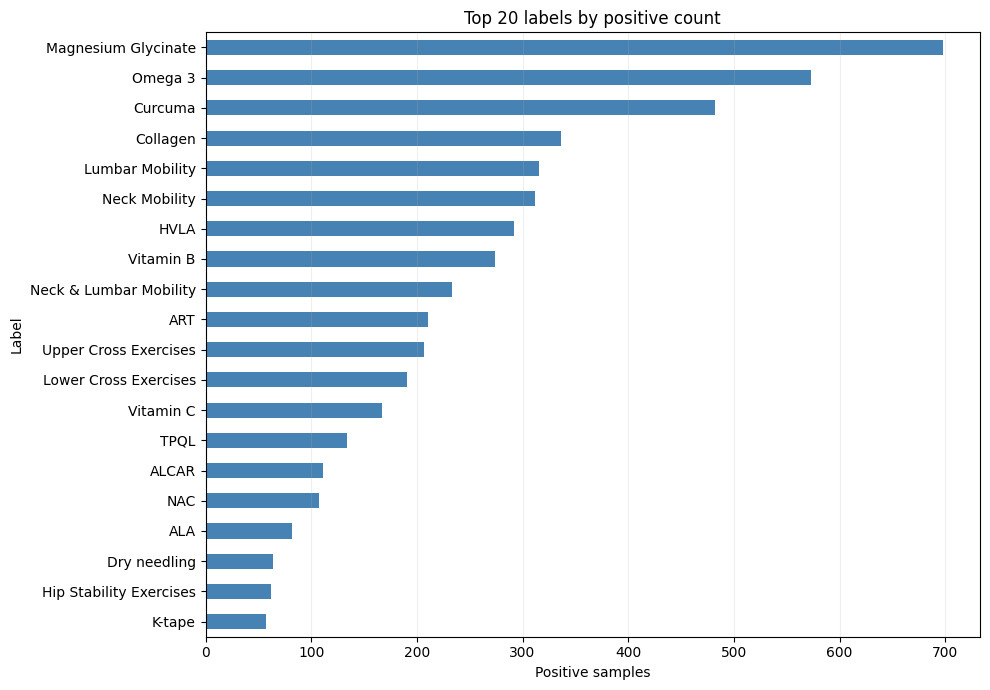

,positive_count
Magnesium Glycinate,698
Omega 3,573
Curcuma,482
Collagen,336
Lumbar Mobility,316
Neck Mobility,312
HVLA,292
Vitamin B,274
Neck & Lumbar Mobility,233
ART,211


In [11]:
TOP_N_POSITIVE_LABELS = 20
label_positive_counts = (
    raw[project_config["labels"]]
    .eq(1)
    .sum()
    .sort_values(ascending=False)
    .head(TOP_N_POSITIVE_LABELS)
)

fig, axis = plt.subplots(figsize=(10, 7))
label_positive_counts.sort_values().plot.barh(ax=axis, color="steelblue")
axis.set(
    xlabel="Positive samples",
    ylabel="Label",
    title=f"Top {len(label_positive_counts)} labels by positive count",
)
axis.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()
label_positive_counts.to_frame("positive_count")

## Simple preprocessing

Normalize headers and strings, remove the empty trailer row, and convert the visit-count field to numeric. No missing values are imputed here.

In [12]:
processed = raw.copy()
processed.columns = [" ".join(str(name).split()) for name in processed.columns]
processed = processed.replace(r"^\s*$", pd.NA, regex=True)
for column in processed.select_dtypes(include="object"):
    processed[column] = processed[column].map(
        lambda value: value.strip() if isinstance(value, str) else value
    )

rows_before = len(processed)
processed = processed.loc[processed["ID"].notna()].copy()
processed["ID"] = processed["ID"].astype("string")
print(f"Removed {rows_before - len(processed)} row(s) without an ID")

Removed 1 row(s) without an ID


In [13]:
visit_column = "Number of visits Code"
numeric_visits = pd.to_numeric(processed[visit_column], errors="coerce")
invalid_visits = processed[visit_column].notna() & numeric_visits.isna()
display(processed.loc[invalid_visits, ["ID", visit_column]])
processed[visit_column] = numeric_visits
processed = processed.reset_index(drop=True)

,ID,Number of visits Code
897,5874,18-thg 1
1080,5476,29-thg 1


In [14]:
output_path = ROOT / "data/preprocessed/bmra_student_project.parquet"
output_path.parent.mkdir(parents=True, exist_ok=True)
processed.to_parquet(output_path, index=False)
print(f"Wrote {processed.shape[0]:,} rows x {processed.shape[1]:,} columns to {output_path}")
print(f"Preserved missing cells: {processed.isna().sum().sum():,}")
processed.head()

Wrote 1,537 rows x 402 columns to /media/chnguyen47/ADATA/Projects/BMRA_modular_MLC/data/preprocessed/bmra_student_project.parquet
Preserved missing cells: 4,082


,STT,ID,Country Code,Age,"Gender (0 = female, 1 = male)",Abdominal Hernia,Ankle Dorsiflexion Deficit,Ankle Edema,Ankle Instability,Ankle Sprain History,...,Number of visits Code,Diagnosing imaging Code,Adverse Postural & Sleep-Position Habits,Health-Promoting Physical Activity & Exercise,Sedentary & Prolonged Static Behaviors,Occupational & Repetitive Mechanical Stressors,Adverse Substance & Stimulant Consumption,"Psychosocial, Sleep & Circadian Stressors",Dietary & Nutritional Habits,Adverse Driving & Mechanical Exposure
0,1.0,5583,30.0,41.0,1.0,0.0,0.0,0.0,0.0,0.0,...,NaN,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,5585,25.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2,3.0,5590,30.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,5595,25.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,...,NaN,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,5599,17.0,41.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
